Total constituents (Quark jets): 1669999
Total constituents (Gluon jets): 2660906


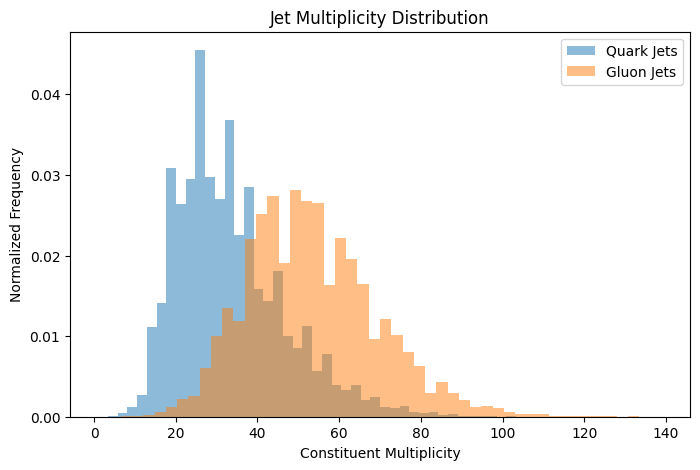

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = np.load('QG_jets.npz')
X = data['X'] # (100000, 139, 4) -> [pT, y, phi, pdgid]
y = data['y'] # (100000,) -> 0=gluon, 1=quark

# Masks for Quarks and Gluons
quark_mask = (y == 1)
gluon_mask = (y == 0)

# (i) Handling Zero-Padding for Constituent Counts
# A constituent is real if its pT > 0 (or any feature is non-zero)
multiplicities = np.sum(X[:, :, 0] > 0, axis=1)

q_multi = multiplicities[quark_mask]
g_multi = multiplicities[gluon_mask]

print(f"Total constituents (Quark jets): {np.sum(q_multi)}")
print(f"Total constituents (Gluon jets): {np.sum(g_multi)}")

# (ii) Plot Multiplicity Distribution
plt.figure(figsize=(8, 5))
plt.hist(q_multi, bins=50, alpha=0.5, label='Quark Jets', density=True)
plt.hist(g_multi, bins=50, alpha=0.5, label='Gluon Jets', density=True)
plt.xlabel('Constituent Multiplicity')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.title('Jet Multiplicity Distribution')
plt.show()

# (iii) Leading Constituent pT and Eta
# Since they are sorted by pT in the dataset, index 0 is the leading one
leading_pt = X[:, 0, 0]
leading_eta = X[:, 0, 1]

# Plotting these follows the same hist pattern as above...

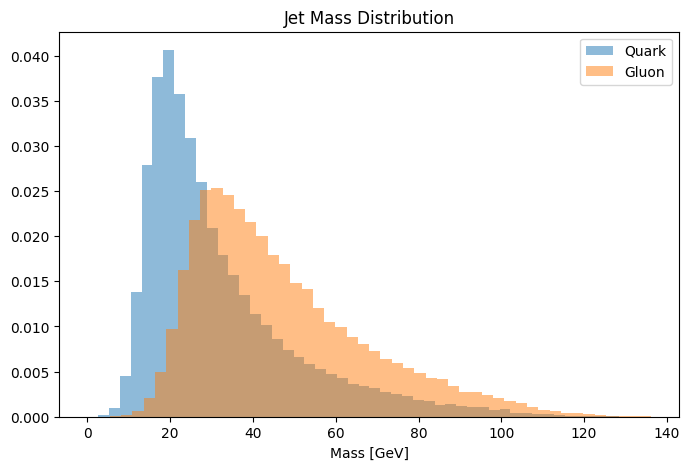

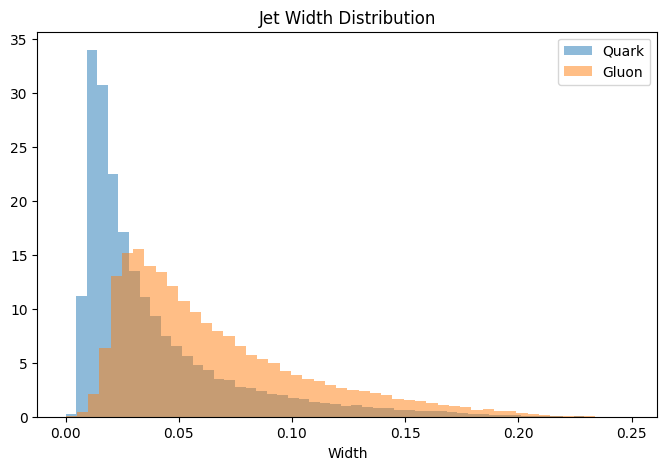

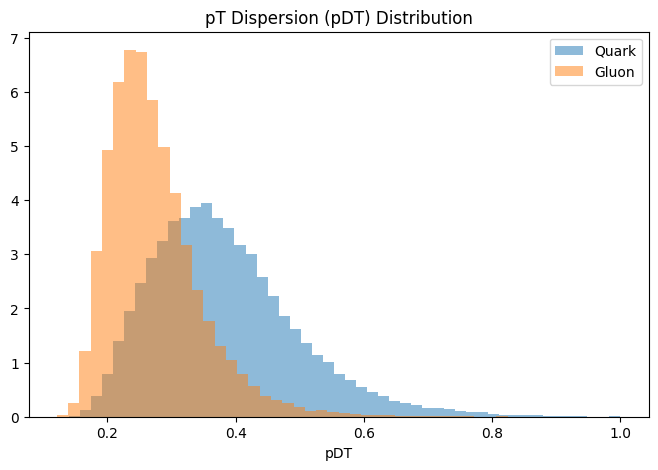

In [5]:
# Constants/Inputs
pt = X[:, :, 0]
eta = X[:, :, 1]
phi = X[:, :, 2]

# 1. Convert to Cartesian 4-momenta (Standard approximation for massless constituents)
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)
e = pt * np.cosh(eta)

# 2. Jet-level 4-momenta (sum of constituents)
# We use np.sum with axis=1 to sum across particles in each jet
E_jet = np.sum(e, axis=1)
px_jet = np.sum(px, axis=1)
py_jet = np.sum(py, axis=1)
pz_jet = np.sum(pz, axis=1)
pt_jet = np.sqrt(px_jet**2 + py_jet**2)
eta_jet = np.arcsinh(pz_jet / pt_jet)
phi_jet = np.arctan2(py_jet, px_jet)

# (i) Jet Mass
m_jet = np.sqrt(np.maximum(0, E_jet**2 - (px_jet**2 + py_jet**2 + pz_jet**2)))

# (ii) Jet Width (w)
# Calculate deltaR for all constituents relative to their own jet axis
d_eta = eta - eta_jet[:, np.newaxis]
d_phi = np.remainder(phi - phi_jet[:, np.newaxis] + np.pi, 2*np.pi) - np.pi
dr = np.sqrt(d_eta**2 + d_phi**2)

width = np.sum(pt * dr, axis=1) / np.sum(pt, axis=1)

# (iii) pT Dispersion (pDT)
pdt = np.sqrt(np.sum(pt**2, axis=1)) / np.sum(pt, axis=1)

# Visualization helper
def plot_compare(data, title, xlabel):
    plt.figure(figsize=(8, 5))
    plt.hist(data[quark_mask], bins=50, alpha=0.5, label='Quark', density=True)
    plt.hist(data[gluon_mask], bins=50, alpha=0.5, label='Gluon', density=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

plot_compare(m_jet, "Jet Mass Distribution", "Mass [GeV]")
plot_compare(width, "Jet Width Distribution", "Width")
plot_compare(pdt, "pT Dispersion (pDT) Distribution", "pDT")

Quark Jet COM Momentum sum: 3.79e-12
Gluon Jet COM Momentum sum: 4.95e-13


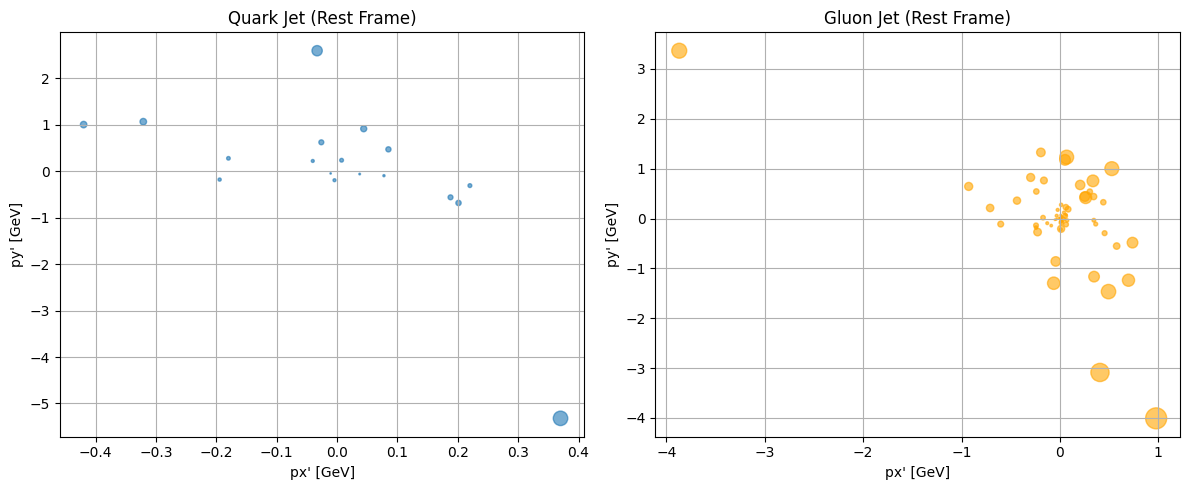

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def lorentz_boost(E, px, py, pz, bx, by, bz):
    """Boosts 4-momenta given a boost vector beta = (bx, by, bz)."""
    b2 = bx**2 + by**2 + bz**2
    if b2 == 0: return E, px, py, pz
    gamma = 1.0 / np.sqrt(1.0 - b2)
    bp = bx*px + by*py + bz*pz
    gamma2 = (gamma - 1.0) / b2
    Ep = gamma * (E + bp)
    pxp = px + gamma*bx*E + gamma2*bp*bx
    pyp = py + gamma*by*E + gamma2*bp*by
    pzp = pz + gamma*bz*E + gamma2*bp*bz
    return Ep, pxp, pyp, pzp

def boost_to_rest_frame(jet_constituents):
    """jet_constituents: Nx4 numpy array of [E, px, py, pz]"""
    E_jet, px_jet, py_jet, pz_jet = np.sum(jet_constituents, axis=0)
    # Negative beta to boost INTO the rest frame
    bx, by, bz = -px_jet/E_jet, -py_jet/E_jet, -pz_jet/E_jet
    Ep, pxp, pyp, pzp = lorentz_boost(jet_constituents[:,0], jet_constituents[:,1], 
                                     jet_constituents[:,2], jet_constituents[:,3], 
                                     bx, by, bz)
    return np.column_stack((Ep, pxp, pyp, pzp))

def get_jet_constituents_4vec(jet_idx):
    mask = X[jet_idx, :, 0] > 0
    return np.column_stack((e[jet_idx, mask], px[jet_idx, mask], 
                            py[jet_idx, mask], pz[jet_idx, mask]))

# Execution
q_idx = np.where(quark_mask)[0][0]
g_idx = np.where(gluon_mask)[0][0]

q_rest = boost_to_rest_frame(get_jet_constituents_4vec(q_idx))
g_rest = boost_to_rest_frame(get_jet_constituents_4vec(g_idx))

# Verify momentum vanishes
print(f"Quark Jet COM Momentum sum: {np.abs(np.sum(q_rest[:, 1:4], axis=0)).max():.2e}")
print(f"Gluon Jet COM Momentum sum: {np.abs(np.sum(g_rest[:, 1:4], axis=0)).max():.2e}")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(q_rest[:, 1], q_rest[:, 2], s=q_rest[:, 0]*20, alpha=0.6)
ax[0].set_title("Quark Jet (Rest Frame)")
ax[1].scatter(g_rest[:, 1], g_rest[:, 2], s=g_rest[:, 0]*20, alpha=0.6, color='orange')
ax[1].set_title("Gluon Jet (Rest Frame)")
for a in ax:
    a.set_xlabel("px' [GeV]"); a.set_ylabel("py' [GeV]"); a.grid(True)
plt.tight_layout()
plt.show()

In [7]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.2 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 4.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 4.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 4.1 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 4.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 4.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.0 MB/s  0:00:02

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
  


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Re-calculating physics features...
Training Random Forest Classifier...


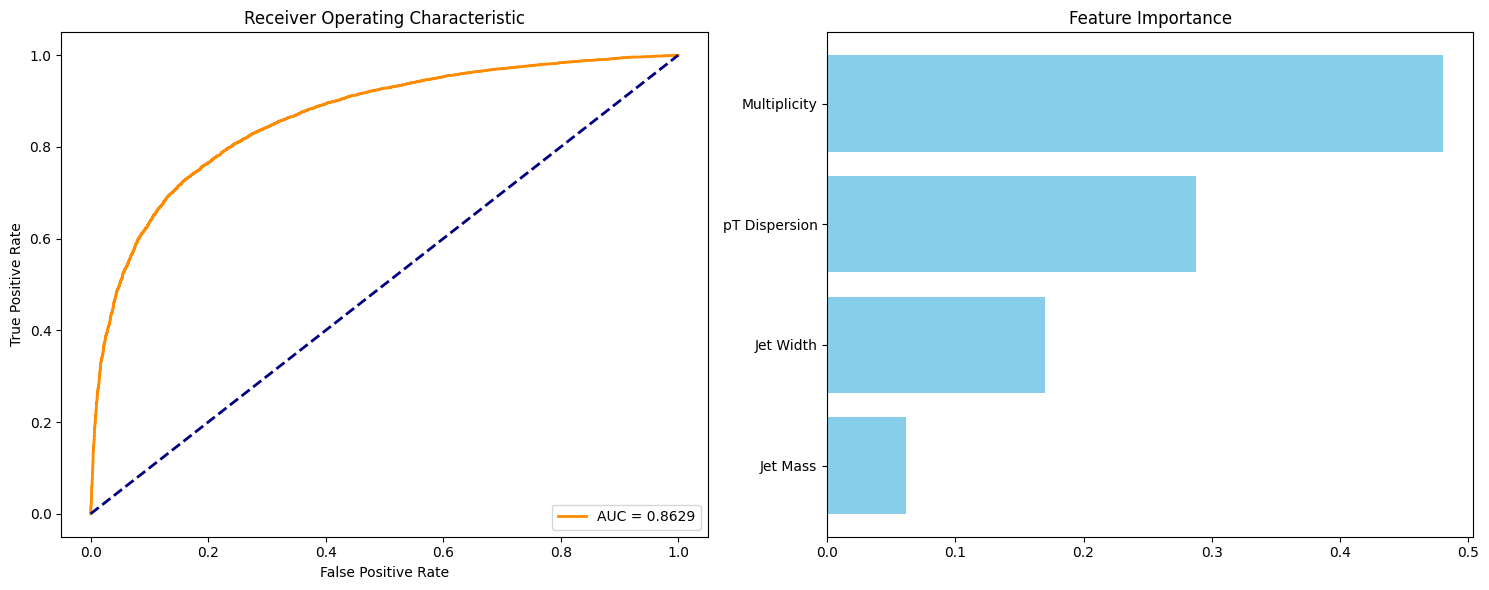

Final Test AUC Score: 0.8629


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

print("Re-calculating physics features...")
# 1. Re-calculate Kinematics (Ensures no NameErrors)
pt = X[:, :, 0]
eta = X[:, :, 1]
phi = X[:, :, 2]

px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)
e = pt * np.cosh(eta)

# Jet-level 4-momenta
E_jet = np.sum(e, axis=1)
px_jet = np.sum(px, axis=1)
py_jet = np.sum(py, axis=1)
pz_jet = np.sum(pz, axis=1)
pt_jet = np.sqrt(px_jet**2 + py_jet**2)
phi_jet = np.arctan2(py_jet, px_jet)

# 2. Re-calculate Observables
m_jet = np.sqrt(np.maximum(0, E_jet**2 - (px_jet**2 + py_jet**2 + pz_jet**2)))
d_eta = eta - np.arcsinh(pz_jet / pt_jet)[:, np.newaxis]
d_phi = np.remainder(phi - phi_jet[:, np.newaxis] + np.pi, 2*np.pi) - np.pi
dr = np.sqrt(d_eta**2 + d_phi**2)
width = np.sum(pt * dr, axis=1) / np.sum(pt, axis=1)
pdt = np.sqrt(np.sum(pt**2, axis=1)) / np.sum(pt, axis=1)
multiplicities = np.sum(pt > 0, axis=1)

# 3. Prepare Feature Matrix
features = np.column_stack((m_jet, width, pdt, multiplicities))
feature_names = ['Jet Mass', 'Jet Width', 'pT Dispersion', 'Multiplicity']

# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

# 5. Train Random Forest
print("Training Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# 6. Diagnostics
y_score = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_title('Receiver Operating Characteristic')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

# Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)
ax2.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
ax2.set_yticks(range(len(indices)))
ax2.set_yticklabels([feature_names[i] for i in indices])
ax2.set_title('Feature Importance')

plt.tight_layout()
plt.show()

print(f"Final Test AUC Score: {roc_auc:.4f}")